# S&P 100 SEC Filings: Data Overview

**Chapter 23: Knowledge Graphs for Financial AI**

**Docker image**: `ml4t`

This notebook loads pre-downloaded 10-K and 8-K filings for S&P 100 companies
and previews the data that feeds the knowledge graph construction pipeline.

**Learning Objectives**:
- Understand the scale and structure of SEC filing data for KG construction
- Inspect text excerpt quality (supplier mentions, event descriptions)
- Verify data coverage across companies and years

**Book Reference**: Chapter 23, Section 23.2 (Constructing Financial Knowledge Graphs)

**Data Download**: Filing data is acquired via the unified SEC download script:
```bash
uv run python data/equities/fundamentals/filings_download.py --form 10-K --universe sp100 --years 2020-2025
uv run python data/equities/fundamentals/filings_download.py --form 8-K --universe sp100 --years 2020-2025
```
See Chapter 4 for details on SEC EDGAR data acquisition.

**Prerequisites**: Run the SEC filing download script above, or use the staged
parquet artifacts from the data bundle (loaded here via `load_sec_filings`).

In [1]:
"""Preview S&P 100 SEC filings for the knowledge graph pipeline."""

import json
import logging

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from matplotlib.colors import ListedColormap

from data import load_sec_filings
from utils.style import COLORS, FIGSIZE, add_message_title, show_with_alt

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

In [2]:
MAX_DISPLAY = 10

### Input Contract

The staged Parquet files must preserve the required filing schema, unique
symbol-accession keys, consistent form labels, and exact text-length metadata.

In [3]:
def validate_filings(filings: pl.DataFrame, expected_form: str) -> None:
    """Fail when a staged filing table violates its reader-facing contract."""
    required = {
        "symbol",
        "cik",
        "form",
        "filing_date",
        "accession_no",
        "company_name",
        "year",
        "text",
        "text_length",
    }
    assert required <= set(filings.columns), f"Missing columns: {required - set(filings.columns)}"
    assert filings.filter(pl.any_horizontal(pl.col(list(required)).is_null())).is_empty()
    assert filings.select(pl.struct(["symbol", "accession_no"]).is_duplicated().sum()).item() == 0
    assert filings["form"].unique().to_list() == [expected_form]
    assert filings.filter(pl.col("year") != pl.col("filing_date").dt.year()).is_empty()
    assert filings.filter(pl.col("text").str.len_chars() != pl.col("text_length")).is_empty()

## 10-K Annual Reports

Annual reports contain supplier relationships, risk factors, and business
descriptions that feed the supply chain knowledge graph.

In [4]:
filings_10k = load_sec_filings("10-K", universe="sp100")
validate_filings(filings_10k, "10-K")

print(f"10-K filings: {len(filings_10k):,}")
print(f"Companies: {filings_10k['symbol'].n_unique()}")
if "year" in filings_10k.columns:
    print(f"Year range: {filings_10k['year'].min()}-{filings_10k['year'].max()}")
print(f"Total text: {filings_10k['text_length'].sum():,} chars")
print(f"Avg text per filing: {filings_10k['text_length'].mean():,.0f} chars")

10-K filings: 601
Companies: 101
Year range: 2020-2025
Total text: 7,286,532 chars
Avg text per filing: 12,124 chars


In [5]:
filings_10k.select(pl.exclude("text")).head(MAX_DISPLAY)

symbol,cik,form,filing_date,period_end,accession_no,company_name,year,text_length
str,str,str,date,date,str,str,i64,i64
"""AAPL""","""0000320193""","""10-K""",2020-10-30,2020-09-26,"""0000320193-20-000096""","""Apple Inc.""",2020,12000
"""AAPL""","""0000320193""","""10-K""",2021-10-29,2021-09-25,"""0000320193-21-000105""","""Apple Inc.""",2021,12000
"""AAPL""","""0000320193""","""10-K""",2022-10-28,2022-09-24,"""0000320193-22-000108""","""Apple Inc.""",2022,12000
"""AAPL""","""0000320193""","""10-K""",2023-11-03,2023-09-30,"""0000320193-23-000106""","""Apple Inc.""",2023,12000
"""AAPL""","""0000320193""","""10-K""",2024-11-01,2024-09-28,"""0000320193-24-000123""","""Apple Inc.""",2024,12000
"""AAPL""","""0000320193""","""10-K""",2025-10-31,2025-09-27,"""0000320193-25-000079""","""Apple Inc.""",2025,12000
"""ABBV""","""0001551152""","""10-K""",2020-02-21,2019-12-31,"""0001551152-20-000007""","""AbbVie Inc.""",2020,12000
"""ABBV""","""0001551152""","""10-K""",2021-02-19,2020-12-31,"""0001551152-21-000008""","""AbbVie Inc.""",2021,12000
"""ABBV""","""0001551152""","""10-K""",2022-02-18,2021-12-31,"""0001551152-22-000007""","""AbbVie Inc.""",2022,12000


## 8-K Event Filings

Current reports contain discrete corporate events (M&A, leadership changes,
material agreements) used for temporal knowledge graph construction.

In [6]:
filings_8k = load_sec_filings("8-K", universe="sp100")
validate_filings(filings_8k, "8-K")

print(f"8-K filings: {len(filings_8k):,}")
print(f"Companies: {filings_8k['symbol'].n_unique()}")
print(f"Avg text: {filings_8k['text_length'].mean():,.0f} chars")

filings_8k.select(pl.exclude("text")).head(MAX_DISPLAY)

8-K filings: 1,249
Companies: 101
Avg text: 6,239 chars


symbol,cik,form,filing_date,period_end,accession_no,company_name,year,text_length
str,str,str,date,date,str,str,i64,i64
"""AAPL""","""0000320193""","""8-K""",2020-08-20,2020-08-13,"""0001193125-20-225672""","""Apple Inc.""",2020,8000
"""AAPL""","""0000320193""","""8-K""",2020-10-29,2020-10-29,"""0000320193-20-000094""","""Apple Inc.""",2020,5105
"""AAPL""","""0000320193""","""8-K""",2021-10-28,2021-10-28,"""0000320193-21-000104""","""Apple Inc.""",2021,5105
"""AAPL""","""0000320193""","""8-K""",2021-11-12,2021-11-09,"""0001193125-21-328151""","""Apple Inc.""",2021,6096
"""AAPL""","""0000320193""","""8-K""",2022-10-27,2022-10-27,"""0000320193-22-000107""","""Apple Inc.""",2022,5105
"""AAPL""","""0000320193""","""8-K""",2022-11-07,2022-11-06,"""0001193125-22-278435""","""Apple Inc.""",2022,4785
"""AAPL""","""0000320193""","""8-K""",2023-05-10,2023-05-08,"""0001140361-23-023909""","""Apple Inc.""",2023,8000
"""AAPL""","""0000320193""","""8-K""",2023-11-02,2023-11-02,"""0000320193-23-000104""","""Apple Inc.""",2023,4988
"""AAPL""","""0000320193""","""8-K""",2024-09-10,2024-09-10,"""0001140361-24-040659""","""Apple Inc.""",2024,7135


## Coverage Matrix

Which companies have 10-K filings for which years?

In [7]:
if "year" in filings_10k.columns:
    coverage = (
        filings_10k.group_by("year")
        .agg(pl.col("symbol").n_unique().alias("companies"), pl.len().alias("filings"))
        .sort("year")
    )

### Filing coverage

One cell per company-year. Two details decide whether the picture is
readable, and the notebook got both wrong before this pass.

**The columns have to be put in year order.** `pivot(on="year")` returns
columns in the order the years happen to appear in the frame, which after a
`unique()` is arbitrary - here it came out 2022, 2024, 2025, 2020, 2023,
2021 - while the axis was labelled with a sorted year list. Every column in
the rendered heatmap carried the wrong year, and the one company with a gap
appeared to be missing the wrong ones.

**The rows have to be ordered so the gaps are visible.** The panel is nearly
complete, so a few missing cells among six hundred, in alphabetical order,
are a scatter of pixels nobody will find. Sorting by coverage puts the
incomplete companies at the top where the chart can be read.

Panel: 101 companies x 6 years = 606 cells
Missing company-years: 5
Companies with a gap: {'BLK': 1}


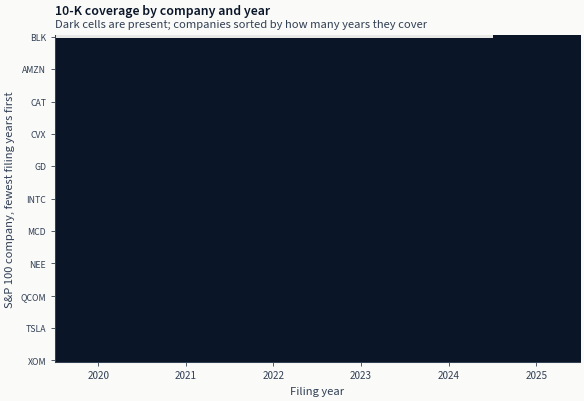

In [8]:
if "year" in filings_10k.columns:
    years = sorted(filings_10k["year"].unique().to_list())
    presence_df = (
        filings_10k.select("symbol", "year")
        .unique()
        .with_columns(pl.lit(1).alias("present"))
        .pivot(index="symbol", on="year", values="present")
        .fill_null(0)
        # Column order comes from the pivot, not from the data. Name the years.
        .select("symbol", *[str(year) for year in years])
        .with_columns(pl.sum_horizontal([str(year) for year in years]).alias("years_present"))
        .sort(["years_present", "symbol"])
    )
    symbols = presence_df["symbol"].to_list()
    presence = presence_df.select([str(year) for year in years]).to_numpy()
    missing_company_years = int(presence.size - presence.sum())
    incomplete = presence_df.filter(pl.col("years_present") < len(years))
    print(f"Panel: {len(symbols)} companies x {len(years)} years = {presence.size} cells")
    print(f"Missing company-years: {missing_company_years}")
    print(f"Companies with a gap: {dict(incomplete.select('symbol', 'years_present').iter_rows())}")

    fig, ax = plt.subplots(figsize=FIGSIZE["single_tall"], constrained_layout=True)
    coverage_cmap = ListedColormap([COLORS["silver_muted"], COLORS["blue"]])
    ax.imshow(presence, aspect="auto", cmap=coverage_cmap, interpolation="nearest")
    ax.set_xticks(range(len(years)))
    ax.set_xticklabels(years)
    y_positions = list(range(0, len(symbols), 10))
    ax.set_yticks(y_positions)
    ax.set_yticklabels([symbols[i] for i in y_positions], fontsize=7)
    ax.set_xlabel("Filing year")
    ax.set_ylabel("S&P 100 company, fewest filing years first")
    add_message_title(
        ax,
        "10-K coverage by company and year",
        subtitle="Dark cells are present; companies sorted by how many years they cover",
    )
    show_with_alt(
        fig,
        "A tall two-colour grid, one row per S&P 100 company and one column per filing year "
        "from 2020 to 2025, with dark cells marking a filing present. Almost the entire "
        "panel is dark. The rows are ordered by how many years each company covers, so the "
        "only visible light cells are in the first row at the top, where a single company "
        "is missing every year but the last.",
    )

A missing cell is a coverage fact and not evidence about its cause. A company
can be absent because it joined the index late, because it changed its filer
identity, or because the download missed it, and the panel cannot tell those
apart. Downstream work should carry the gap rather than impute a filing into
it.

## Text Length Distribution

Compare text excerpt lengths between 10-K and 8-K filings. 10-K filings
provide longer narrative sections (supplier mentions, risk factors) while
8-K filings are shorter event disclosures.

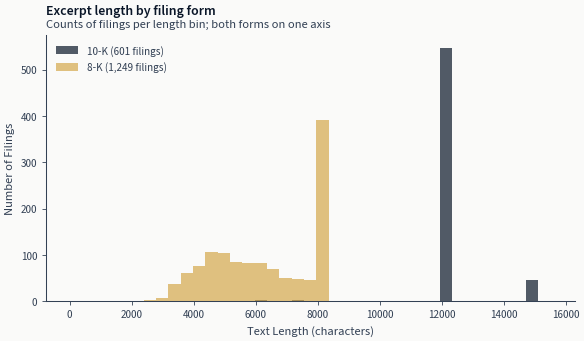

In [9]:
fig, ax = plt.subplots(figsize=FIGSIZE["single"], constrained_layout=True)
bins = np.linspace(
    0, max(filings_10k["text_length"].max(), filings_8k["text_length"].max()) + 500, 40
)
ax.hist(
    filings_10k["text_length"].to_numpy(),
    bins=bins,
    alpha=0.7,
    label=f"10-K ({len(filings_10k):,} filings)",
    color=COLORS["blue"],
)
ax.hist(
    filings_8k["text_length"].to_numpy(),
    bins=bins,
    alpha=0.7,
    label=f"8-K ({len(filings_8k):,} filings)",
    color=COLORS["amber"],
)
ax.set_xlabel("Text Length (characters)")
ax.set_ylabel("Number of Filings")
modal_10k_length = int(filings_10k["text_length"].mode()[0])
add_message_title(
    ax,
    "Excerpt length by filing form",
    subtitle="Counts of filings per length bin; both forms on one axis",
)
ax.legend()
show_with_alt(
    fig,
    "Two overlaid histograms of extracted text length in characters. The 10-K series is "
    "concentrated in one tall spike well to the right, with a smaller spike beyond it and "
    "almost nothing elsewhere. The 8-K series sits entirely to the left of the 10-K spike, "
    "spread across a range of shorter lengths rather than concentrated at one value.",
)

The 10-K spikes are the download's fixed extraction windows rather than a
property of annual reports - `01_sec_filing_pipeline` in chapter 22 takes
that apart. The 8-K distribution is spread because event disclosures vary in
length and the 8-K rule keeps the opening rather than a fixed window.

So length is a diagnostic of the extraction, not a measure of how much a
filing says, and it is not comparable across the two forms.

## Text Quality Check

Preview text excerpts to verify supplier mention extraction works.

In [10]:
sample = filings_10k.filter(pl.col("text_length") > 5000).head(3)
for row in sample.iter_rows(named=True):
    print(f"\n{'=' * 60}")
    print(f"{row['symbol']} ({row.get('year', 'N/A')}): {row['text_length']:,} chars")
    print(row["text"][:500] + "...")


AAPL (2020): 12,000 chars
ctures, and by emulating the Company’s products and infringing on its intellectual property.

The Company’s ability to compete successfully depends heavily on ensuring the continuing and timely introduction of innovative new products, services and technologies to the marketplace. The Company believes it is unique in that it designs and develops nearly the entire solution for its products, including the hardware, operating system, numerous software applications and related services. Principal com...

AAPL (2021): 12,000 chars
ek to compete primarily through aggressive pricing and very low cost structures, and by imitating the Company’s products and infringing on its intellectual property.

The Company’s ability to compete successfully depends heavily on ensuring the continuing and timely introduction of innovative new products, services and technologies to the marketplace. The Company designs and develops nearly the entire solution for its products, including 

## Key Takeaways

1. 10-K filings provide structured annual narratives - supplier mentions and
   risk factors are the primary input for supply chain KG construction
2. 8-K filings capture discrete events - M&A, leadership, material agreements
   feed the temporal edge layer
3. Coverage is nearly complete, but gaps remain explicit rather than imputed
4. Fixed extraction windows make text length a pipeline diagnostic, not a
   direct measure of filing informativeness
5. A pivot returns its columns in whatever order the data supplied them.
   Labelling those columns from a separately sorted list mislabels every one
   of them, and a heatmap gives no hint that it happened - name the columns
   when you select them

**Next**: [`02_supply_chain_kg_construction`](02_supply_chain_kg_construction.ipynb)
extracts supply-chain relations from these filings with a local LLM.

In [11]:
completion_record = {
    "filings_10k": filings_10k.height,
    "filings_8k": filings_8k.height,
    "companies_10k": filings_10k["symbol"].n_unique(),
    "companies_8k": filings_8k["symbol"].n_unique(),
    "year_min": filings_10k["year"].min(),
    "year_max": filings_10k["year"].max(),
    "missing_company_years": missing_company_years,
    "modal_10k_text_length": modal_10k_length,
}
print("COMPLETION_RECORD=" + json.dumps(completion_record, sort_keys=True))

COMPLETION_RECORD={"companies_10k": 101, "companies_8k": 101, "filings_10k": 601, "filings_8k": 1249, "missing_company_years": 5, "modal_10k_text_length": 12000, "year_max": 2025, "year_min": 2020}
